<a href="https://colab.research.google.com/github/padhma4782/AI-ML-Practice-sheets/blob/main/Guvi_Zen_DS_Session_27_28_ML%20Intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iteration 0: Loss = 52.589009460171134
Iteration 100: Loss = 0.5265362710186242
Iteration 200: Loss = 0.2704372039382105
Iteration 300: Loss = 0.14190881906957883
Iteration 400: Loss = 0.07446568938141963
Iteration 500: Loss = 0.03907536509597734
Iteration 600: Loss = 0.020504532625292976
Iteration 700: Loss = 0.010759614328593712
Iteration 800: Loss = 0.005646034592238042
Iteration 900: Loss = 0.0029627183320162314
Final Parameter Values (theta):
[[3.92648682]
 [3.06523043]]


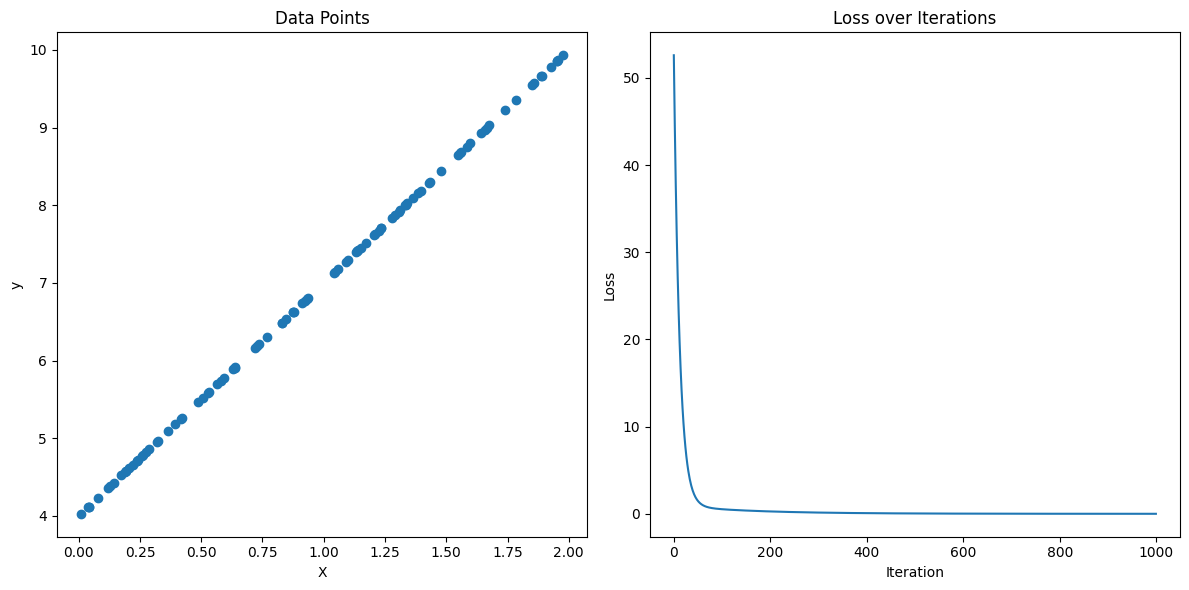

In [ ]:
# Linear regression : Without any package using

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
#y = 4 + 3 * X + np.random.randn(100, 1)
y = 4 + 3 * X

# Linear regression parameters
learning_rate = 0.01
n_iterations = 1000
m = len(X)

# Append a column of ones to X for the bias term
X_b = np.c_[np.ones((m, 1)), X]

# Initialize the parameters
theta = np.random.randn(2, 1)

# Lists to store loss and iteration values
loss_history = []

# Perform gradient descent
for iteration in range(n_iterations):
    y_pred = X_b.dot(theta) # taking dot product of weight and agumented data
    loss = np.mean((y_pred - y) ** 2) # calculating loss
    loss_history.append(loss)

    gradients = 2 / m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - learning_rate * gradients

    if iteration % 100 == 0:
        print(f"Iteration {iteration}: Loss = {loss}")

# Final parameter values
print("Final Parameter Values (theta):")
print(theta)

# Plot the data, regression line, and loss
plt.figure(figsize=(12, 6))

# Data scatter plot
plt.subplot(121)
plt.scatter(X, y)
plt.title("Data Points")
plt.xlabel("X")
plt.ylabel("y")

# Loss over iterations
plt.subplot(122)
plt.plot(range(n_iterations), loss_history)
plt.title("Loss over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()


(100, 2)


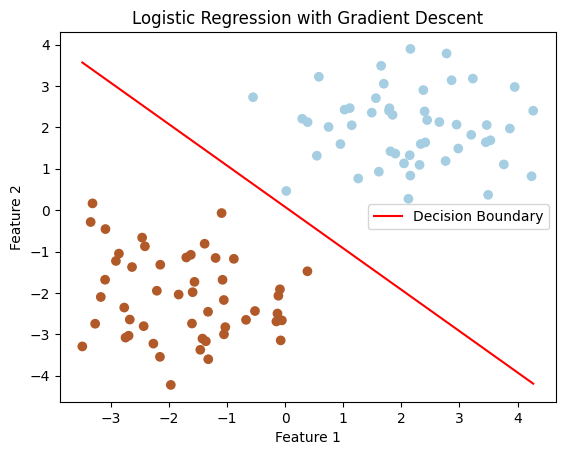

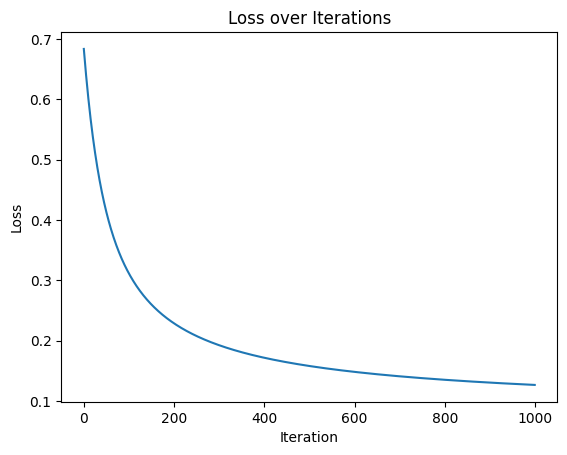

In [ ]:
# Logistic Regression for Binary classification

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data with two clusters
np.random.seed(0)

# Cluster 1
cluster1_x = np.random.normal(2, 1, 50)
cluster1_y = np.random.normal(2, 1, 50)

# Cluster 2
cluster2_x = np.random.normal(-2, 1, 50)
cluster2_y = np.random.normal(-2, 1, 50)

# Concatenate data
X = np.concatenate((cluster1_x, cluster2_x))
Y = np.concatenate((cluster1_y, cluster2_y))

# Labels (0 for Cluster 1, 1 for Cluster 2)
labels = np.array([0] * 50 + [1] * 50)

# Add a bias term (intercept) to the feature matrix
X_b = np.c_[np.ones((len(X), 1)), X]

print(X_b.shape)

# Initialize parameters and hyperparameters
theta = np.zeros(X_b.shape[1])  # Initialize theta with zeros

learning_rate = 0.01
n_iterations = 1000

# Perform logistic regression with gradient descent
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    return -(1/m) * (np.log(h).T.dot(y) + np.log(1 - h).T.dot(1 - y))

def gradient_descent(X, y, theta, learning_rate, n_iterations):
    m = len(y)
    cost_history = []
    for _ in range(n_iterations):
        h = sigmoid(X.dot(theta))
        gradient = (1/m) * X.T.dot(h - y)
        theta -= learning_rate * gradient
        cost = compute_cost(theta, X, y)
        cost_history.append(cost)
    return theta, cost_history

theta, cost_history = gradient_descent(X_b, labels, theta, learning_rate, n_iterations)

# Plot the data points
plt.scatter(X, Y, c=labels, cmap=plt.cm.Paired)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# Plot the decision boundary
x_boundary = np.array([np.min(X), np.max(X)])
y_boundary = (-1/theta[1]) * (theta[0] + theta[1] * x_boundary)
plt.plot(x_boundary, y_boundary, color='r', label='Decision Boundary')

plt.legend()
plt.title('Logistic Regression with Gradient Descent')
plt.show()

# Plot how the loss changes over iterations
plt.plot(range(n_iterations), cost_history)
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()


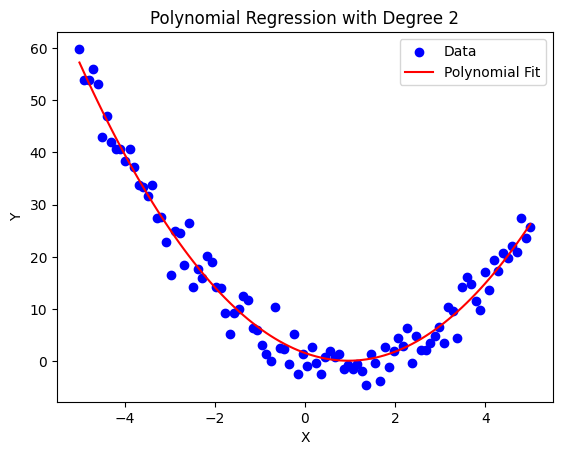

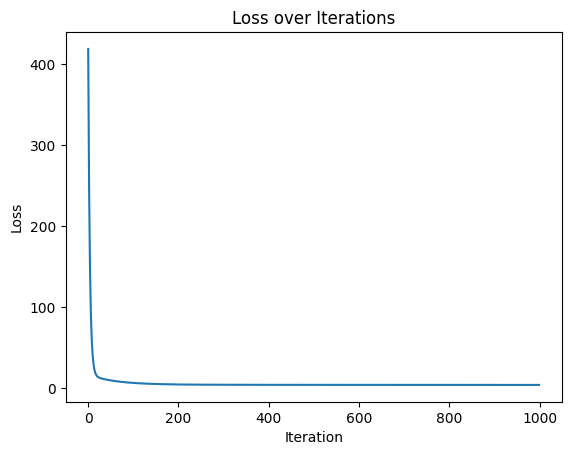

[ 1.63654235 -3.08885695  1.60436169]


In [ ]:
# Polynomial regresion

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data using a polynomial function
np.random.seed(0)

# True polynomial coefficients
true_coeffs = [1.5, -3, 2]

# Generate X values
X = np.linspace(-5, 5, 100)

# Generate synthetic data using the polynomial function with added noise
Y = true_coeffs[0] * X**2 + true_coeffs[1] * X + true_coeffs[2] + np.random.normal(0, 3, len(X))

# Initialize parameters and hyperparameters
degree = 2  # Polynomial degree
learning_rate = 0.001
n_iterations = 1000

# Initialize coefficients for the polynomial
coeffs = np.random.randn(degree + 1)

# Perform polynomial regression with gradient descent
def polynomial_regression(X, coeffs):
    return np.dot(np.column_stack([X**i for i in range(degree + 1)]), coeffs)

def compute_cost(X, Y, coeffs):
    m = len(Y)
    predictions = polynomial_regression(X, coeffs)
    return (1 / (2 * m)) * np.sum((predictions - Y) ** 2)

def gradient_descent(X, Y, coeffs, learning_rate, n_iterations):
    m = len(Y)
    cost_history = []
    for _ in range(n_iterations):
        predictions = polynomial_regression(X, coeffs)
        errors = predictions - Y
        gradient = (1 / m) * np.dot(np.column_stack([X**i for i in range(degree + 1)]).T, errors)
        coeffs -= learning_rate * gradient
        cost = compute_cost(X, Y, coeffs)
        cost_history.append(cost)
    return coeffs, cost_history

# Perform gradient descent to fit the polynomial
coeffs, cost_history = gradient_descent(X, Y, coeffs, learning_rate, n_iterations)

# Plot the data points
plt.scatter(X, Y, label='Data', color='blue')

# Plot the polynomial fit
fit_x = np.linspace(-5, 5, 100)
fit_y = polynomial_regression(fit_x, coeffs)
plt.plot(fit_x, fit_y, label='Polynomial Fit', color='red')

plt.legend()
plt.title(f'Polynomial Regression with Degree {degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

# Plot how the loss changes over iterations
plt.plot(range(n_iterations), cost_history)
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()


print(coeffs)